In [1]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import tensorflow as tf

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical 

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import keras



I0000 00:00:1785656527.558921  456633 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785656527.602370  456633 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785656528.931906  456633 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
val_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split_3classes/validation/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)


# Pour avoir le nom des classes 
class_names_val = val_ds.class_names


# %%
test_ds = image_dataset_from_directory(
    directory="../../../COVID-19_Radiography_Dataset_split_3classes/test/",                                 
    image_size=(224, 224),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='rgb'
)

# Pour avoir le nom des classes 
class_names_test = test_ds.class_names


val_ds_pred = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_pred = test_ds.map(lambda x, y: (preprocess_input(x), y))



Found 2083 files belonging to 3 classes.
Found 2084 files belonging to 3 classes.


W0000 00:00:1785656529.974671  456633 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
@keras.saving.register_keras_serializable()
class SparseF1Score(tf.keras.metrics.F1Score):
    """F1Score de Keras adaptée aux labels sparses (entiers) plutôt que one-hot."""
    def __init__(self, num_classes=4, **kwargs):
        super().__init__(**kwargs)
        self.num_classes_ = num_classes

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), depth=self.num_classes_)
        return super().update_state(y_true, y_pred, sample_weight)
    


In [4]:
#model_loaded = load_model('vgg16_head.keras')
model_loaded = load_model('vgg16_finetuned_3classes.keras')
model_loaded.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden_layer (Dense)      │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 29,072,078 (110.90 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,291,210 (54.52 MB)

In [5]:

# jeu de test
test_pred = model_loaded.predict(test_ds_pred)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds_pred)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)


# sauvegarde sous la forme npy 
model_name = "vgg16_3classes"
y_true_test_model_name="y_true_test_"+model_name+".npy"
y_prob_test__model_name="y_prob_test_"+model_name+".npy"
np.save(y_true_test_model_name, y_true_test_class)  # changer le nom selon le modèle
np.save(y_prob_test__model_name, test_pred)


I0000 00:00:1785656530.772321  457162 service.cc:153] XLA service 0x7f9ce0038d50 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785656530.772358  457162 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1785656530.785571  457162 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785656530.913892  457162 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step


In [6]:
def evaluer(model, y, y_pred, titre):
    """Affiche accuracy, classification_report et matrice de confusion."""
   
    acc = accuracy_score(y, y_pred)

    print(f"===== {titre} =====")
    print(f"Accuracy : {acc:.4f}\n")
    print(classification_report(y, y_pred, zero_division=0))

    cm = confusion_matrix(y, y_pred,normalize='true')
    class_names = test_ds.class_names
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_names)
    cm_display.plot()
    plt.tight_layout()
    plt.show()
    return acc


===== vgg16_3classes - Validation =====
Accuracy : 0.9001

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       338
           1       0.93      0.92      0.93      1013
           2       0.90      0.90      0.90       732

    accuracy                           0.90      2083
   macro avg       0.88      0.89      0.88      2083
weighted avg       0.90      0.90      0.90      2083



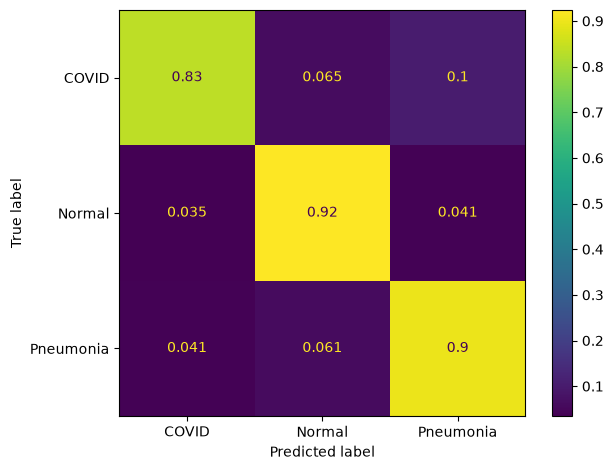

===== vgg16_3classes - Test =====
Accuracy : 0.9083

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       337
           1       0.93      0.94      0.94      1014
           2       0.92      0.90      0.91       733

    accuracy                           0.91      2084
   macro avg       0.89      0.89      0.89      2084
weighted avg       0.91      0.91      0.91      2084



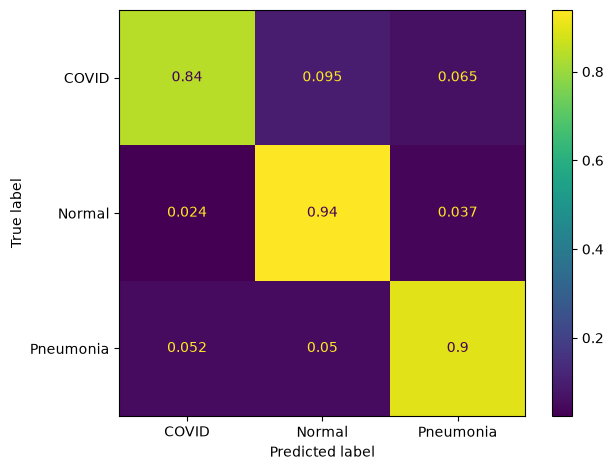

In [7]:
acc_val  = evaluer(model_loaded, y_true_val_class, val_pred_class,  model_name + " - Validation")
acc_test = evaluer(model_loaded, y_true_test_class, test_pred_class,  model_name + " - Test")
